# Superstore Sales Analysis — Exploratory Data Analysis (EDA)

**Tools:** Python · Pandas · Matplotlib · Seaborn · Jupyter Notebook

## Project Overview
This project analyses **4 years (2011–2014) of Superstore order data** to understand *what drives sales and profit* and *where the business is losing money*.

**Dataset:** `SuperStoreOrders.csv` — 51,290 transactions and 21 columns (order details, customer, segment, region, product, sales, quantity, discount, profit, shipping cost, etc.)

## Business Questions
1. What are the overall sales, profit and profit margin?
2. Which categories, sub-categories, regions and customer segments perform best and worst?
3. Do discounts hurt profit?
4. Which customers and products are making losses, and why?
5. How do sales and profit change over time (trend and seasonality)?

## Contents
1. Setup and Data Loading
2. Data Cleaning
3. Data Quality Checks
4. Overall Business KPIs
5. Category Analysis
6. Sub-Category Analysis
7. Deep Dive: Why are Tables Losing Money?
8. Discount Impact on Profit
9. Region Analysis
10. Customer Segment Analysis
11. Customer Analysis
12. Time-Based Analysis (Trend and Seasonality)
13. Product Analysis
14. Distributions
15. Outlier Detection
16. Relationships Between Variables
17. Visual Summary
18. Final Insights, Recommendations and Next Steps

> **Note:** Insights are based only on this dataset. Correlation does not prove causation.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Place SuperStoreOrders.csv inside the "data" folder (see README)
df = pd.read_csv("data/SuperStoreOrders.csv")

## 2. Data Cleaning
First look at the data (shape, columns, data types, missing values, duplicates), then fix the data types:
- `order_date` and `ship_date` are stored as text in mixed formats, so they are converted to datetime.
- `sales` is stored as text with commas (e.g. `"1,234"`), so it is converted to a number.

In [3]:
# First 5 rows
display(df.head())

# Dataset dimensions
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data information
print("\nDataset Info:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

print("\nValue count")
print(df["category"].value_counts(normalize = True) * 100)

print("\nsub-category values count")
print(df["sub_category"].value_counts())

print("\nDate format change")
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format = "mixed",
    dayfirst = True
)

df["ship_date"] =  pd.to_datetime(
    df["ship_date"],
    format = "mixed",
    dayfirst = True
)

print(df[["order_date", "ship_date"]].head())
print(df[["order_date", "ship_date"]].dtypes)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


Shape: (51290, 21)

Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  objec

In [4]:
# Convert sales from text (with commas) to float
df["sales"] = (
    df["sales"]
    .str.replace(",", "")
    .astype(float)
)

In [5]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

### Insights — Data Cleaning
- The dataset has **51,290 rows and 21 columns**, with **no missing values and no duplicate rows**.
- `sales` was stored as text with commas and the dates were in mixed formats. After converting them, `sales` is `float64` and both date columns are `datetime64`.
- The data covers **Jan 2011 to Dec 2014** (4 years).

## 3. Data Quality Checks
Checking for impossible values: zero or negative sales, quantity ≤ 0, and discounts outside 0–100%.

In [6]:
zero_sales = df[df["sales"] == 0]

zero_sales[
    [
        "order_id",
        "product_name",
        "category",
        "sub_category",
        "sales",
        "quantity",
        "discount",
        "profit"
    ]
]

,order_id,product_name,category,sub_category,sales,quantity,discount,profit
40017,US-2014-102288,Hoover Replacement Belt for Commercial Guardsm...,Office Supplies,Appliances,0.0,1,0.8,-1.11


In [7]:
df[["sales", "quantity", "discount", "profit", "shipping_cost"]].describe()

,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.641740,26.375915
std,487.567175,2.278766,0.212280,174.424113,57.296804
min,0.000000,1.000000,0.000000,-6599.978000,0.000000
25%,31.000000,2.000000,0.000000,0.000000,2.610000
50%,85.000000,3.000000,0.000000,9.240000,7.790000
75%,251.000000,5.000000,0.200000,36.810000,24.450000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000


In [8]:
quality_summary = pd.DataFrame({
    "Metric":[
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Negative Sales",
        "Zero Sales",
        "Invalid Quantity",
        "Invalid Discount"
    ],
    "Count":[
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["sales"] < 0).sum(),
        (df["sales"] == 0).sum(),
        (df["quantity"] <= 0).sum(),
        ((df["discount"] < 0) | (df["discount"] > 1)).sum()
    ]
})

quality_summary
        

,Metric,Count
0,Total Rows,51290
1,Total Columns,21
2,Missing Values,0
3,Duplicate Rows,0
4,Negative Sales,0
5,Zero Sales,1
6,Invalid Quantity,0
7,Invalid Discount,0


### Insights — Data Quality
- Only **1 row** has zero sales (Hoover Replacement Belt, 80% discount, small loss of \$1.11). It is a valid transaction, so it is kept.
- There are **no negative sales, no invalid quantities and no invalid discounts** (discount ranges from 0% to 85%).
- `profit` ranges from **-\$6,599.98 to +\$8,399.98**. Negative profit is normal in retail (loss-making sales), so these rows are kept for analysis.
- The data is clean enough to move on to analysis without dropping any rows.

## 4. Overall Business KPIs

In [9]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_quantity = df["quantity"].sum()
total_orders = df["order_id"].nunique()

profit_margin = (total_profit / total_sales) * 100
average_order_value = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Order Value:", round(average_order_value, 2))

Total Sales: 12642905.0
Total Profit: 1469034.82
Total Quantity: 178312
Total Orders: 25035
Profit Margin: 11.62 %
Average Order Value: 505.01


Summary table of key numbers (also exported as a CSV file):

In [10]:
summary = {
    "Total Transactions": len(df),
    "Total Sales": df["sales"].sum(),
    "Total Profit": df["profit"].sum(),
    "Average Sales": df["sales"].mean(),
    "Average Profit": df["profit"].mean(),
    "Average Discount": df["discount"].mean(),
    "Average Quantity": df["quantity"].mean(),
    "Highest Sale": df["sales"].max(),
    "Highest Profit": df["profit"].max(),
    "Biggest Loss": df["profit"].min()
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value:,}")

Total Transactions: 51,290
Total Sales: 12,642,905.00
Total Profit: 1,469,034.82
Average Sales: 246.50
Average Profit: 28.64
Average Discount: 0.14
Average Quantity: 3.48
Highest Sale: 22,638.00
Highest Profit: 8,399.98
Biggest Loss: -6,599.98


In [11]:
import os
os.makedirs("outputs", exist_ok=True)

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df.to_csv("outputs/Business_Summary.csv", index=False)

summary_df

,Metric,Value
0,Total Transactions,5.129000e+04
1,Total Sales,1.264290e+07
2,Total Profit,1.469035e+06
3,Average Sales,2.464984e+02
4,Average Profit,2.864174e+01
5,Average Discount,1.429075e-01
6,Average Quantity,3.476545e+00
7,Highest Sale,2.263800e+04
8,Highest Profit,8.399976e+03
9,Biggest Loss,-6.599978e+03


### Insights — Business KPIs
- **Total sales: \$12.64M** and **total profit: \$1.47M**, giving an overall **profit margin of 11.62%**.
- **25,035 unique orders** with an **average order value of about \$505**. The 51,290 rows are individual transactions (order lines), roughly 2 per order.
- A total of **178,312 units** were sold, about 3.5 units per transaction.
- Profit margin of ~11.6% is a healthy baseline. The next sections look at *where* it is higher or lower than this average.

## 5. Category Analysis

**Average sale value per transaction by category**

In [12]:
category_avg_sale = (
    df.groupby("category")["sales"]
    .agg(["sum", "mean", "count"])
    .reset_index()
)

display(category_avg_sale)

,category,sum,mean,count
0,Furniture,4110884.0,416.249899,9876
1,Office Supplies,3787330.0,121.105426,31273
2,Technology,4744691.0,467.872103,10141


**Sales, profit and quantity by category (with profit margin)**

In [13]:
category_analysis = (
    df.groupby("category")
    .agg(
        total_sales = ("sales", "sum"),
        total_profit = ("profit", "sum"),
        total_quantity = ("quantity", "sum")
    )
    .reset_index()
)

category_analysis["profit_margin"] = (
    category_analysis["total_profit"] 
    / category_analysis["total_sales"]
    * 100
).round(2)

category_analysis

,category,total_sales,total_profit,total_quantity,profit_margin
0,Furniture,4110884.0,286782.25380,34954,6.98
1,Office Supplies,3787330.0,518473.83430,108182,13.69
2,Technology,4744691.0,663778.73318,35176,13.99


**Categories ranked by sales**

In [14]:
category_analysis.sort_values(
    "total_sales",
    ascending = False
)

,category,total_sales,total_profit,total_quantity,profit_margin
2,Technology,4744691.0,663778.73318,35176,13.99
0,Furniture,4110884.0,286782.25380,34954,6.98
1,Office Supplies,3787330.0,518473.83430,108182,13.69


### Insights — Category
- **Technology** is the strongest category: highest sales (**\$4.74M, 37.5% of total**), highest profit (**\$664K, 45.2% of total**) and the best margin (**13.99%**).
- **Furniture** has high sales (\$4.11M, 32.5% of total) but a very low margin of only **6.98%**, about half of the other two categories. It brings 32.5% of sales but only 19.5% of profit.
- **Office Supplies** has the lowest sales (\$3.79M) but a strong margin (**13.69%**) and sells by far the most units (**108,182, about 61% of all units**) because the items are cheap (average sale about \$121 vs \$416 for Furniture and \$468 for Technology).
- **Takeaway:** higher sales does not always mean higher profit. Furniture needs a closer look because its margin is much lower than the other categories.

## 6. Sub-Category Analysis

In [15]:
subcategory_analysis = (
    df.groupby(["category", "sub_category"])
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum")
      )
      .reset_index()
)

subcategory_analysis["profit_margin"] = (
    subcategory_analysis["total_profit"] /
    subcategory_analysis["total_sales"] * 100
).round(2)

**Sub-categories ranked by sales (with profit margin)**

In [16]:
subcategory_analysis = subcategory_analysis.sort_values(
    "total_sales",
    ascending = False
)
subcategory_analysis

,category,sub_category,total_sales,total_profit,total_quantity,profit_margin
16,Technology,Phones,1706874.0,216717.00580,11870,12.70
14,Technology,Copiers,1509439.0,258567.54818,7454,17.13
1,Furniture,Chairs,1501682.0,141973.79750,12336,9.45
0,Furniture,Bookcases,1466559.0,161924.41950,8310,11.04
11,Office Supplies,Storage,1127124.0,108461.48980,16917,9.62
4,Office Supplies,Appliances,1011081.0,141680.58940,6078,14.01
15,Technology,Machines,779071.0,58867.87300,4906,7.56
3,Furniture,Tables,757034.0,-64083.38870,3083,-8.47
13,Technology,Accessories,749307.0,129626.30620,10946,17.30
6,Office Supplies,Binders,461952.0,72449.84600,21429,15.68


**Loss-making sub-categories** (total profit below zero)

In [17]:
loss_making_subcategories = (
    subcategory_analysis[subcategory_analysis["total_profit"] < 0]
    .sort_values("total_profit")
)

loss_making_subcategories

,category,sub_category,total_sales,total_profit,total_quantity,profit_margin
3,Furniture,Tables,757034.0,-64083.3887,3083,-8.47


**High sales but low margin** (sales above 500K and margin below 10%)

In [18]:
high_sales_low_margin = subcategory_analysis[
    (subcategory_analysis["total_sales"] > 500000) &
    (subcategory_analysis["profit_margin"] < 10)
    ]
high_sales_low_margin.sort_values(
    "total_sales",
    ascending = False
)

,category,sub_category,total_sales,total_profit,total_quantity,profit_margin
1,Furniture,Chairs,1501682.0,141973.7975,12336,9.45
11,Office Supplies,Storage,1127124.0,108461.4898,16917,9.62
15,Technology,Machines,779071.0,58867.8730,4906,7.56
3,Furniture,Tables,757034.0,-64083.3887,3083,-8.47


### Insights — Sub-Category
- **Top sellers:** Phones (\$1.71M), Copiers (\$1.51M) and Chairs (\$1.50M).
- **Most profitable:** Copiers (**\$259K**, margin 17.13%), Phones (\$217K) and Bookcases (\$162K).
- **Tables is the only sub-category that loses money:** sales of \$757K but a **loss of \$64K (margin -8.47%)**. It is the 8th highest in sales, so a lot of revenue is being turned into a loss.
- **High sales but low margin:** Chairs (9.45%), Storage (9.62%), Machines (7.56%) and Tables (-8.47%). These sell well but keep very little profit.
- **High margin but small sales:** Paper (24.2%) and Labels (20.4%) are very profitable per sale, but their total sales are small.
- **Takeaway:** the first thing to investigate is *why Tables loses money*, which is done in the next section.

## 7. Deep Dive: Why are Tables Losing Money?
Tables is the only loss-making sub-category, so it is analysed in more detail: first by discount level, then by product and region.

**Tables: performance at each discount level**

In [19]:
tables_data = df[df["sub_category"] == "Tables"]

tables_discount_analysis = (
    tables_data.groupby("discount")
    .agg(
        total_sales = ("sales", "sum"),
        total_profit = ("profit", "sum"),
        total_quantity = ("quantity", "sum"),
        transaction = ("order_id", "count")
    )
    .reset_index()
)

tables_discount_analysis["profit_margin"] = (
    tables_discount_analysis["total_profit"]
    / tables_discount_analysis["total_sales"] * 100 
).round(2)

tables_discount_analysis.sort_values("discount")

,discount,total_sales,total_profit,total_quantity,transaction,profit_margin
0,0.00,261807.0,60447.1997,716,208,23.09
1,0.10,3481.0,795.0270,8,3,22.84
2,0.20,157721.0,7215.5360,688,183,4.57
3,0.30,104747.0,-11960.4786,413,116,-11.42
4,0.35,54159.0,-9122.6490,169,45,-16.84
5,0.40,52162.0,-17105.1808,313,85,-32.79
6,0.45,8032.0,-3596.3026,56,13,-44.77
7,0.47,32502.0,-10680.2751,125,34,-32.86
8,0.50,26505.0,-15049.8623,187,52,-56.78
9,0.55,6308.0,-3150.6720,36,10,-49.95


In [20]:
tables_product_analysis = (
    tables_data.groupby("product_name")
    .agg(
        total_sales = ("sales", "sum"),
        total_profit = ("profit", "sum"),
        total_quantity = ("quantity", "sum"),
        avg_discount = ("discount", "mean"),
        transaction = ("order_id", "count")
    )
    .reset_index()
)

tables_product_analysis["profit_margin"] = (
    tables_product_analysis["total_profit"]
    / tables_product_analysis["total_sales"] * 100
).round(2)

**Tables: 10 worst products by profit**

In [21]:
tables_top_loss_products = (
    tables_product_analysis
    .sort_values("total_profit")
    .head(10)
)
tables_top_loss_products

,product_name,total_sales,total_profit,total_quantity,avg_discount,transaction,profit_margin
49,"Bevis Round Table, Adjustable Height",5655.0,-3649.8940,22,0.460000,5,-64.54
38,"Bevis Computer Table, Fully Assembled",11176.0,-3509.5638,43,0.353077,13,-31.40
73,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9918.0,-2876.1156,27,0.280000,5,-29.00
61,"Bevis Wood Table, with Bottom Storage",11134.0,-2782.5880,34,0.320000,10,-24.99
158,"Lesro Training Table, Rectangular",2712.0,-2581.2834,25,0.582000,5,-95.18
15,"Barricks Conference Table, Rectangular",3664.0,-2487.9675,10,0.350000,3,-67.90
40,"Bevis Conference Table, Fully Assembled",14885.0,-2443.0893,26,0.302500,8,-16.41
151,"Lesro Round Table, Adjustable Height",3961.0,-2402.9760,19,0.434000,5,-60.67
144,"Lesro Computer Table, Fully Assembled",7224.0,-2322.8380,34,0.400000,7,-32.15
76,"Chromcraft Coffee Table, Fully Assembled",1226.0,-1960.6960,19,0.587500,4,-159.93


**Tables: 10 best products by profit**

In [22]:
tables_top_profit_products = (
    tables_product_analysis
    .sort_values("total_profit", ascending=False)
    .head(10)
)

tables_top_profit_products

,product_name,total_sales,total_profit,total_quantity,avg_discount,transaction,profit_margin
79,"Chromcraft Computer Table, Adjustable Height",7582.0,3009.1070,22,0.207143,7,39.69
127,"Hon Training Table, Adjustable Height",5726.0,1911.7890,19,0.190000,5,33.39
22,"Barricks Training Table, Adjustable Height",8701.0,1758.9735,30,0.170000,5,20.22
14,"Barricks Conference Table, Fully Assembled",14930.0,1574.6550,21,0.260000,5,10.55
128,"Hon Training Table, Fully Assembled",5552.0,1341.8515,22,0.220000,5,24.17
51,"Bevis Round Table, Rectangular",8107.0,1299.4872,23,0.224286,7,16.03
41,"Bevis Conference Table, Rectangular",3686.0,1037.9200,7,0.300000,3,28.16
84,"Chromcraft Conference Table, Fully Assembled",8042.0,996.4080,12,0.100000,2,12.39
97,"Chromcraft Wood Table, Adjustable Height",4945.0,872.2020,14,0.300000,3,17.64
148,"Lesro Conference Table, Rectangular",11002.0,860.6300,23,0.356667,6,7.82


**Tables: performance by region**

In [23]:
tables_region_analysis = (
    tables_data.groupby("region")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        avg_discount=("discount", "mean"),
        transactions=("order_id", "count")
    )
    .reset_index()
)

tables_region_analysis["profit_margin"] = (
    tables_region_analysis["total_profit"]
    / tables_region_analysis["total_sales"]
    * 100
).round(2)

tables_region_analysis.sort_values(
    "total_profit"
)

,region,total_sales,total_profit,total_quantity,avg_discount,transactions,profit_margin
10,South,104894.0,-27012.3219,483,0.364015,132,-25.75
3,Central,133126.0,-21550.1069,624,0.325602,166,-16.19
11,Southeast Asia,52452.0,-18618.3051,224,0.480000,59,-35.50
6,East,39142.0,-11025.3801,271,0.373750,80,-28.17
8,North Asia,54299.0,-5470.5780,167,0.326190,42,-10.07
9,Oceania,66833.0,-229.7190,181,0.273585,53,-0.34
2,Caribbean,23660.0,63.3880,108,0.285185,27,0.27
1,Canada,850.0,300.1800,2,0.000000,2,35.32
12,West,84755.0,1482.6073,481,0.200000,116,1.75
5,EMEA,39331.0,2764.2510,102,0.164444,45,7.03


### Insights — Tables
- **Discount is the main reason.** Tables made **+\$68.5K** when discounts were 0–20%, but lost **-\$132.5K** at discounts of 30% or more. Net result: **-\$64.1K**.
- At **0% discount**, Tables earned a healthy margin of about **23%**. At 20% discount the margin dropped to about 4.6%, and **every discount level from 30% upward is loss-making** (the worst is 70%, with a loss of \$34K).
- **Worst products:** Bevis Round Table, Adjustable Height (-\$3.65K, average discount 46%) and Bevis Computer Table, Fully Assembled (-\$3.51K). **Best product:** Chromcraft Computer Table, Adjustable Height (+\$3.0K, margin 39.7%).
- **Regions:** South (-\$27.0K), Central (-\$21.6K), Southeast Asia (-\$18.6K) and East (-\$11.0K) lose the most, and they also have a high average discount on Tables (33–48%). Regions with lower discounts (North, Africa, EMEA, Central Asia) were profitable.
- **Takeaway:** Tables is not a bad product line. It becomes loss-making because of heavy discounting. This idea is tested for the whole business in the next section.

## 8. Discount Impact on Profit
Discounts are grouped into buckets (0%, 1–10%, 11–20%, 21–30%, 31–40%, 40%+) to see how profit changes as discounts increase.

In [24]:
df["discount_bucket"] = pd.cut(
    df["discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.40, 1],
    labels=[
        "0%",
        "1–10%",
        "11–20%",
        "21–30%",
        "31–40%",
        "40%+"
    ]
)

In [25]:
discount_analysis = (
    df.groupby("discount_bucket", observed=False)
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum"),
          transactions=("order_id", "count")
      )
      .reset_index()
)

discount_analysis["profit_margin"] = (
    discount_analysis["total_profit"]
    / discount_analysis["total_sales"]
    * 100
).round(2)

discount_analysis

,discount_bucket,total_sales,total_profit,total_quantity,transactions,profit_margin
0,0%,6992734.0,1.770695e+06,98768,29009,25.32
1,1–10%,1962633.0,3.397668e+05,17607,4679,17.31
2,11–20%,1757296.0,1.732548e+05,23394,6274,9.86
3,21–30%,382540.0,-2.115561e+04,3679,967,-5.53
4,31–40%,701367.0,-1.661154e+05,12415,3400,-23.68
5,40%+,846335.0,-6.274110e+05,22449,6961,-74.13


### Insights — Discount
- Profit margin **falls steadily as the discount increases**: 25.3% (no discount) → 17.3% (1–10%) → 9.9% (11–20%) → **-5.5% (21–30%)** → **-23.7% (31–40%)** → **-74.1% (above 40%)**.
- **Discounts above 20% are loss-making.** They make up **22% of all transactions** (11,328 rows) and 15% of sales (\$1.93M), but caused a **combined loss of about \$815K**.
- Transactions with **no discount** (57% of all transactions) earned **\$1.77M profit, which is more than the company's total profit of \$1.47M**. The deep discounts wiped out about \$0.8M of it.
- **Takeaway:** a discount cap of around 20% could protect a large part of the profit. This is the most important finding of the project.

## 9. Region Analysis

In [26]:
region_analysis = (
    df.groupby("region")
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum"),
          transactions=("order_id", "count")
      )
      .reset_index()
)

region_analysis["profit_margin"] = (
    region_analysis["total_profit"]
    / region_analysis["total_sales"]
    * 100
).round(2)

region_analysis = region_analysis.sort_values(
    "total_profit",
    ascending=False
)

region_analysis

,region,total_sales,total_profit,total_quantity,transactions,profit_margin
3,Central,2822399.0,311403.98164,41762,11117,11.03
7,North,1248192.0,194597.95252,18021,4785,15.59
8,North Asia,848349.0,165578.42100,8851,2338,19.52
10,South,1600960.0,140355.76618,25206,6645,8.77
4,Central Asia,752839.0,132480.18700,7715,2048,17.60
9,Oceania,1100207.0,121666.64200,12838,3487,11.06
12,West,725514.0,108418.44890,12266,3203,14.94
6,East,678834.0,91522.78000,10618,2848,13.48
0,Africa,783776.0,88871.63100,10564,4587,11.34
5,EMEA,806184.0,43897.97100,11517,5029,5.45


### Insights — Region
- **Central** is the biggest region by far: highest sales (**\$2.82M**) and highest profit (**\$311K**), with a margin (11.0%) close to the company average.
- **Best margins:** North Asia (19.5%), Central Asia (17.6%) and North (15.6%). Canada has the highest margin (26.6%) but its sales are very small (\$67K).
- **Weakest margins:** **Southeast Asia (2.0%)**, EMEA (5.5%) and South (8.8%).
- **Southeast Asia** sells more (\$884K) than Africa (\$784K) but earns only about **1/5 of the profit** (\$17.9K vs \$88.9K). South is also large (\$1.6M sales) with a below-average margin.
- **Takeaway:** these low-margin regions should be checked for heavy discounts (as seen for Tables) and other costs. Shipping cost is a next step, as it is not analysed here.

## 10. Customer Segment Analysis

In [27]:
segment_analysis = (
    df.groupby("segment")
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum"),
          transactions=("order_id", "count")
      )
      .reset_index()
)

segment_analysis["profit_margin"] = (
    segment_analysis["total_profit"]
    / segment_analysis["total_sales"]
    * 100
).round(2)

segment_analysis.sort_values(
    "total_profit",
    ascending=False
)

,segment,total_sales,total_profit,total_quantity,transactions,profit_margin
0,Consumer,6508141.0,749239.78206,92157,26518,11.51
1,Corporate,3824808.0,442785.85866,53565,15429,11.58
2,Home Office,2309956.0,277009.18056,32590,9343,11.99


### Insights — Customer Segment
- **Consumer** is the largest segment: \$6.51M sales (51.5%) and \$749K profit.
- **Corporate** (30.3% of sales) and **Home Office** (18.3% of sales) follow.
- All three segments have **almost the same profit margin (11.5% to 12.0%)**. Home Office is slightly highest even though it is the smallest.
- **Takeaway:** the segment does not change profitability much. Consumer customers simply bring the most volume, so profit differences come from *what* is sold and *how much discount* is given, not *who* buys.

## 11. Customer Analysis
### Top 10 customers by sales

In [28]:
customer_analysis = (
    df.groupby("customer_name")
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum"),
          transactions=("order_id", "count")
      )
      .reset_index()
)

customer_analysis["profit_margin"] = (
    customer_analysis["total_profit"]
    / customer_analysis["total_sales"]
    * 100
).round(2)

customer_analysis.sort_values(
    "total_sales",
    ascending=False
).head(10)

,customer_name,total_sales,total_profit,total_quantity,transactions,profit_margin
758,Tom Ashbrook,40489.0,6311.97910,284,80,15.59
731,Tamara Chand,37453.0,8672.89890,271,88,23.16
313,Greg Tran,35552.0,5214.13118,310,87,14.67
157,Christopher Conant,35187.0,5603.33370,287,73,15.92
687,Sean Miller,35170.0,-409.70634,169,50,-1.16
73,Bart Watters,32315.0,3595.88590,338,96,11.13
558,Natalie Fritzler,31778.0,1542.82110,325,95,4.85
290,Fred Hopkins,30404.0,4609.29112,290,82,15.16
347,Jane Waco,30288.0,6265.84570,298,75,20.69
335,Hunter Lopez,30246.0,7816.56778,207,53,25.84


### Top 10 customers by profit

In [29]:
customer_analysis.sort_values("total_profit", ascending=False).head(10)

,customer_name,total_sales,total_profit,total_quantity,transactions,profit_margin
731,Tamara Chand,37453.0,8672.89890,271,88,23.16
623,Raymond Buch,29601.0,8453.04950,262,71,28.56
672,Sanjit Chand,26524.0,8205.37990,244,69,30.94
335,Hunter Lopez,30246.0,7816.56778,207,53,25.84
88,Bill Eplett,28480.0,7410.00530,411,102,26.02
323,Harry Marie,28477.0,6958.28640,313,85,24.43
727,Susan Pistek,29020.0,6484.40726,235,68,22.34
542,Mike Gockenbach,23378.0,6458.67620,185,51,27.63
6,Adrian Barton,25125.0,6417.28450,265,77,25.54
758,Tom Ashbrook,40489.0,6311.97910,284,80,15.59


### 10 most loss-making customers

In [30]:
customer_analysis.sort_values("total_profit").head(10)

,customer_name,total_sales,total_profit,total_quantity,transactions,profit_margin
166,Cindy Stewart,13432.0,-6151.55810,153,42,-45.80
478,Luke Foster,13422.0,-3644.34750,246,61,-27.15
308,Grant Thornton,20226.0,-3577.92306,182,48,-17.69
120,Candace McMahon,14798.0,-2798.79060,172,46,-18.91
703,Skye Norling,14225.0,-2637.98050,232,67,-18.54
222,Denise Monton,22051.0,-2597.80290,240,59,-11.78
694,Sharelle Roach,13005.0,-2551.18846,206,52,-19.62
207,David Bremer,6275.0,-2270.69658,116,34,-36.19
685,Sean Braxton,20514.0,-1896.97930,208,53,-9.25
406,Julie Creighton,14996.0,-1889.10592,228,63,-12.60


### Drill-down: the most loss-making customer
The biggest loss-maker is **Cindy Stewart**. Going from category → sub-category → product to find the reason.

In [31]:
cindy_data = df[
    df["customer_name"] == "Cindy Stewart"
]

cindy_category_analysis = (
    cindy_data.groupby("category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        transactions=("order_id", "count"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

cindy_category_analysis["profit_margin"] = (
    cindy_category_analysis["total_profit"]
    / cindy_category_analysis["total_sales"]
    * 100
).round(2)

cindy_category_analysis.sort_values(
    "total_profit"
)

,category,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
2,Technology,6462.0,-6725.6621,25,5,0.2740,-104.08
1,Office Supplies,2606.0,69.0006,89,25,0.0656,2.65
0,Furniture,4364.0,505.1034,39,12,0.0975,11.57


In [32]:
cindy_technology = df[
    (df["customer_name"] == "Cindy Stewart") &
    (df["category"] == "Technology")
]

cindy_technology_subcategory = (
    cindy_technology.groupby("sub_category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        transactions=("order_id", "count"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

cindy_technology_subcategory["profit_margin"] = (
    cindy_technology_subcategory["total_profit"]
    / cindy_technology_subcategory["total_sales"]
    * 100
).round(2)

cindy_technology_subcategory.sort_values(
    "total_profit"
)

,sub_category,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
2,Machines,4896.0,-6409.8980,9,2,0.350,-130.92
0,Accessories,603.0,-469.8441,12,2,0.335,-77.92
1,Copiers,963.0,154.0800,4,1,0.000,16.00


In [33]:
cindy_machines = df[
    (df["customer_name"] == "Cindy Stewart") &
    (df["category"] == "Technology") &
    (df["sub_category"] == "Machines")
]

cindy_machine_products = (
    cindy_machines.groupby("product_name")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        transactions=("order_id", "count"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

cindy_machine_products["profit_margin"] = (
    cindy_machine_products["total_profit"]
    / cindy_machine_products["total_sales"]
    * 100
).round(2)

cindy_machine_products.sort_values(
    "total_profit"
)

,product_name,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
0,Cubify CubeX 3D Printer Double Head Print,4500.0,-6599.978,5,1,0.7,-146.67
1,Lexmark X 9575 Professional All-in-One Color P...,396.0,190.080,4,1,0.0,48.00


### Drill-down: all loss-making customers together

In [34]:
loss_making_customer_names = customer_analysis[
    customer_analysis["total_profit"] < 0
]["customer_name"]

len(loss_making_customer_names)

67

In [35]:
loss_customer_data = df[
    df["customer_name"].isin(loss_making_customer_names)
]

loss_customer_data.shape

(4005, 22)

In [36]:
loss_customer_category = (
    loss_customer_data.groupby("category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        transactions=("order_id", "count"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

loss_customer_category["profit_margin"] = (
    loss_customer_category["total_profit"]
    / loss_customer_category["total_sales"]
    * 100
).round(2)

loss_customer_category.sort_values(
    "total_profit"
)

,category,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
0,Furniture,316026.0,-35178.19370,2811,771,0.223839,-11.13
2,Technology,346610.0,-20833.21194,2608,755,0.192538,-6.01
1,Office Supplies,286215.0,-9501.66110,8510,2479,0.179447,-3.32


In [37]:
loss_customer_subcategory = (
    loss_customer_data.groupby(
        ["category", "sub_category"]
    )
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        transactions=("order_id", "count"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

loss_customer_subcategory["profit_margin"] = (
    loss_customer_subcategory["total_profit"]
    / loss_customer_subcategory["total_sales"]
    * 100
).round(2)

loss_customer_subcategory.sort_values(
    "total_profit"
)

,category,sub_category,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
3,Furniture,Tables,71204.0,-27493.93990,312,77,0.421039,-38.61
15,Technology,Machines,103710.0,-16207.52830,454,139,0.217050,-15.63
6,Office Supplies,Binders,41748.0,-10841.42830,1672,485,0.219959,-25.97
16,Technology,Phones,117015.0,-10383.77450,887,257,0.200623,-8.87
4,Office Supplies,Appliances,74359.0,-9609.20170,463,143,0.209371,-12.92
1,Furniture,Chairs,104954.0,-5287.81400,992,263,0.208099,-5.04
0,Furniture,Bookcases,111987.0,-4546.87300,665,190,0.217947,-4.06
11,Office Supplies,Storage,78045.0,181.85610,1286,380,0.186342,0.23
9,Office Supplies,Labels,5337.0,706.01180,753,212,0.169292,13.23
8,Office Supplies,Fasteners,6267.0,921.24130,634,173,0.145549,14.70


Tables bought by loss-making customers (worst 10 products):

In [38]:
loss_customer_tables = loss_customer_data[
    (loss_customer_data["category"] == "Furniture") &
    (loss_customer_data["sub_category"] == "Tables")
]

loss_customer_tables_products = (
    loss_customer_tables.groupby("product_name")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        transactions=("order_id", "count"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

loss_customer_tables_products["profit_margin"] = (
    loss_customer_tables_products["total_profit"]
    / loss_customer_tables_products["total_sales"]
    * 100
).round(2)

loss_customer_tables_products.sort_values(
    "total_profit"
).head(10)

,product_name,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
6,"Barricks Conference Table, Rectangular",2171.0,-2750.2800,8,1,0.700,-126.68
19,"Bevis Round Table, Adjustable Height",2940.0,-2612.4330,11,2,0.475,-88.86
37,"Hon Conference Table, Rectangular",1287.0,-2380.3500,7,1,0.800,-184.95
4,"Barricks Conference Table, Adjustable Height",1970.0,-1761.0550,6,2,0.350,-89.39
15,"Bevis Computer Table, Fully Assembled",1119.0,-1742.1406,9,2,0.635,-155.69
3,"Barricks Computer Table, Fully Assembled",1855.0,-1294.3503,9,1,0.570,-69.78
23,"Bevis Wood Table, with Bottom Storage",2828.0,-1163.4770,9,2,0.500,-41.14
55,"Lesro Wood Table, Rectangular",1697.0,-1134.6000,7,2,0.425,-66.86
1,"Barricks Coffee Table, Rectangular",1130.0,-1040.9154,9,2,0.585,-92.12
33,"Chromcraft Wood Table, Rectangular",768.0,-819.3760,8,1,0.700,-106.69


### Insights — Customers
- **Tamara Chand** is the most profitable customer (**\$8.7K profit**, 23% margin) and also second in sales. Raymond Buch and Sanjit Chand follow with \$8.5K and \$8.2K profit.
- **Sales is not the same as profit.** Sean Miller is a top-5 customer by sales (\$35K) but made a small loss, while Hunter Lopez earned more profit on lower sales (\$30K sales, 25.8% margin).
- **Cindy Stewart** lost **\$6.2K** in total. The loss comes almost entirely from **one Technology order**: a *Cubify CubeX 3D Printer* sold at a **70% discount** (loss of \$6,600). Her other categories were slightly profitable.
- **67 customers are loss-making overall.** They account for about 7.8% of transactions and a combined loss of about **\$65.5K**. The biggest loss is in Furniture (-\$35.2K), mainly **Tables** (-\$27.5K, average discount 42%).
- Even **Binders**, which are profitable overall (15.7% margin), lose money for these customers (-26% margin).
- **Takeaway:** a few heavily discounted orders can turn a good customer into a loss-making one. Large discounts need an approval step.

## 12. Time-Based Analysis (Trend and Seasonality)

In [39]:
monthly_analysis = (
    df.groupby(
        df["order_date"].dt.to_period("M")
    )
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        transactions=("order_id", "count")
    )
    .reset_index()
)

monthly_analysis["profit_margin"] = (
    monthly_analysis["total_profit"]
    / monthly_analysis["total_sales"]
    * 100
).round(2)

**Monthly sales, profit and month-over-month growth**

In [40]:
monthly_analysis["sales_mom_growth"] = (
    monthly_analysis["total_sales"]
    .pct_change() * 100
).round(2)

monthly_analysis["profit_mom_growth"] = (
    monthly_analysis["total_profit"]
    .pct_change() * 100
).round(2)

monthly_analysis

,order_date,total_sales,total_profit,total_quantity,transactions,profit_margin,sales_mom_growth,profit_mom_growth
0,2011-01,98902.0,8321.80096,1463,433,8.41,NaN,NaN
1,2011-02,91152.0,12417.90698,1224,378,13.62,-7.84,49.22
2,2011-03,145726.0,15303.56826,1836,539,10.50,59.87,23.24
3,2011-04,116927.0,12902.32438,2020,564,11.03,-19.76,-15.69
4,2011-05,146762.0,12183.82870,2013,566,8.30,25.52,-5.57
5,2011-06,215214.0,23415.24702,3112,917,10.88,46.64,92.18
6,2011-07,115518.0,5585.00352,1774,495,4.83,-46.32,-76.15
7,2011-08,207570.0,23713.66772,3035,878,11.42,79.69,324.60
8,2011-09,290230.0,35776.88394,3707,1052,12.33,39.82,50.87
9,2011-10,199070.0,25963.41834,2727,774,13.04,-31.41,-27.43


**Yearly summary**

In [41]:
yearly_analysis = (
    df.groupby(df["order_date"].dt.year)
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        transactions=("order_id", "count")
    )
    .reset_index()
    .rename(columns={"order_date": "year"})
)

yearly_analysis["profit_margin"] = (
    yearly_analysis["total_profit"] / yearly_analysis["total_sales"] * 100
).round(2)

yearly_analysis["sales_yoy_growth"] = (
    yearly_analysis["total_sales"].pct_change() * 100
).round(1)

yearly_analysis

,year,total_sales,total_profit,transactions,profit_margin,sales_yoy_growth
0,2011,2259511.0,248940.81154,8998,11.02,NaN
1,2012,2677493.0,307415.27910,10962,11.48,18.5
2,2013,3405860.0,408512.76018,13799,11.99,27.2
3,2014,4300041.0,504165.97046,17531,11.72,26.3


### Insights — Time Trend
- **Strong growth every year.** Yearly sales grew from **\$2.26M (2011) to \$4.30M (2014), about +90%**. Year-on-year growth was about +18% (2012), +27% (2013) and +26% (2014).
- **Profit grew too**, from about \$249K to \$504K (roughly doubled), and the **profit margin stayed stable at about 11–12%** every year.
- **Seasonality:** the last quarter (Oct–Dec) brings roughly **31–37% of the sales of each year**. The best sales month is **Nov 2014 (\$555K)** and the best profit month is **Sep 2014 (\$68K)**.
- Sales are **lowest in Jan–Feb** (the lowest is Feb 2011, \$91K) and show a **small dip in July every year** right after a strong June.
- **Takeaway:** stock and marketing can be planned for Q4 and June peaks. Growth came from higher sales volume, not from a better margin, so margin improvement (e.g. controlling discounts) is still an opportunity.

## 13. Product Analysis

In [42]:
product_analysis = (
    df.groupby("product_name")
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum"),
          transactions=("order_id", "count"),
          avg_discount=("discount", "mean")
      )
      .reset_index()
)

product_analysis["profit_margin"] = (
    product_analysis["total_profit"]
    / product_analysis["total_sales"]
    * 100
).round(2)

**Top 10 products by sales**

In [43]:
top_sales_products = (
    product_analysis
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_sales_products

,product_name,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
310,"Apple Smart Phone, Full Size",86936.0,5921.5786,171,51,0.106667,6.81
970,"Cisco Smart Phone, Full Size",76441.0,17238.5206,139,38,0.054474,22.55
2415,"Motorola Smart Phone, Full Size",73159.0,17027.1130,134,38,0.147632,23.27
2501,"Nokia Smart Phone, Full Size",71904.0,9938.1955,147,47,0.144468,13.82
866,Canon imageCLASS 2200 Advanced Copier,61600.0,25199.9280,20,5,0.120000,40.91
1837,"Hon Executive Leather Armchair, Adjustable",58200.0,5997.2541,169,49,0.165510,10.30
2631,"Office Star Executive Leather Armchair, Adjust...",50667.0,4710.9840,141,45,0.143778,9.30
1714,"Harbour Creations Executive Leather Armchair, ...",50120.0,10427.3260,142,39,0.178974,20.80
2988,"Samsung Smart Phone, Cordless",48654.0,-198.0900,108,26,0.125385,-0.41
2502,"Nokia Smart Phone, with Caller ID",47880.0,9465.3257,96,24,0.147500,19.77


**Top 10 products by profit**

In [44]:
top_profit_products = (
    product_analysis
    .sort_values("total_profit", ascending=False)
    .head(10)
)

top_profit_products

,product_name,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
866,Canon imageCLASS 2200 Advanced Copier,61600.0,25199.9280,20,5,0.120000,40.91
970,"Cisco Smart Phone, Full Size",76441.0,17238.5206,139,38,0.054474,22.55
2415,"Motorola Smart Phone, Full Size",73159.0,17027.1130,134,38,0.147632,23.27
1926,"Hoover Stove, Red",31664.0,11807.9690,62,15,0.066667,37.29
3098,"Sauder Classic Bookcase, Traditional",39110.0,10672.0730,113,29,0.118966,27.29
1714,"Harbour Creations Executive Leather Armchair, ...",50120.0,10427.3260,142,39,0.178974,20.80
2501,"Nokia Smart Phone, Full Size",71904.0,9938.1955,147,47,0.144468,13.82
971,"Cisco Smart Phone, with Caller ID",43124.0,9786.6408,85,27,0.147037,22.69
2502,"Nokia Smart Phone, with Caller ID",47880.0,9465.3257,96,24,0.147500,19.77
589,"Belkin Router, USB",23473.0,8955.0180,110,32,0.096875,38.15


**10 most loss-making products**

In [45]:
product_analysis.sort_values(
    "total_profit",
    ascending=True
).head(10)

,product_name,total_sales,total_profit,total_quantity,transactions,avg_discount,profit_margin
1007,Cubify CubeX 3D Printer Double Head Print,11100.0,-8879.9704,9,3,0.533333,-80.00
2233,Lexmark MX611dhe Monochrome Laser Printer,16830.0,-4589.9730,18,4,0.400000,-27.27
2414,"Motorola Smart Phone, Cordless",38935.0,-4447.0380,74,23,0.118261,-11.42
1008,Cubify CubeX 3D Printer Triple Head Print,8000.0,-3839.9904,4,1,0.500000,-48.00
614,"Bevis Round Table, Adjustable Height",5655.0,-3649.8940,22,5,0.460000,-64.54
603,"Bevis Computer Table, Fully Assembled",11176.0,-3509.5638,43,13,0.353077,-31.40
2847,"Rogers Lockers, Blue",28215.0,-2893.4908,167,42,0.143571,-10.26
910,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9918.0,-2876.1156,27,5,0.280000,-29.00
627,"Bevis Wood Table, with Bottom Storage",11134.0,-2782.5880,34,10,0.320000,-24.99
2221,"Lesro Training Table, Rectangular",2712.0,-2581.2834,25,5,0.582000,-95.18


### Insights — Products
- **Top sellers are mostly Phones and Copiers.** Apple Smart Phone, Full Size is #1 in sales (\$86.9K) but its margin is only **6.8%**, so it earns much less than Cisco (22.6%) or Motorola (23.3%) full-size phones.
- **Most profitable product:** Canon imageCLASS 2200 Advanced Copier earned **\$25.2K profit from only 20 units** (margin 40.9%, average discount 12%).
- **Biggest loss:** Cubify CubeX 3D Printer, Double Head Print lost **\$8.9K** (average discount 53%). The Lexmark MX611dhe laser printer lost \$4.6K at an average 40% discount.
- **Not every loss is because of discount.** Motorola Smart Phone, Cordless lost \$4.4K with an average discount of only 12%, and Rogers Lockers, Blue lost \$2.9K at 14%. For these, cost and pricing should be checked.
- **Takeaway:** a high-selling product is not always a high-profit product. Products should be judged by profit and margin together.

## 14. Distributions
Checking how sales, profit, quantity and discount are spread. Sales and profit are shown in a zoomed range so the main body of the data is visible.

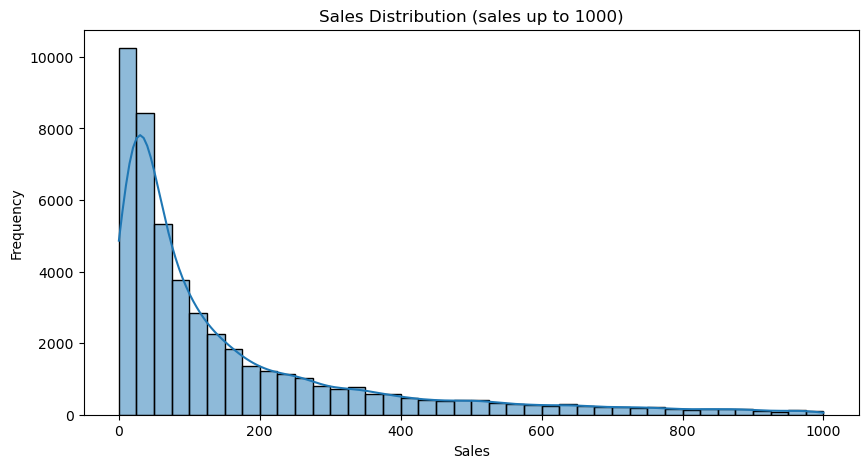

In [46]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df.loc[df["sales"] <= 1000, "sales"],
    bins=40,
    kde=True
)

plt.title("Sales Distribution (sales up to 1000)")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

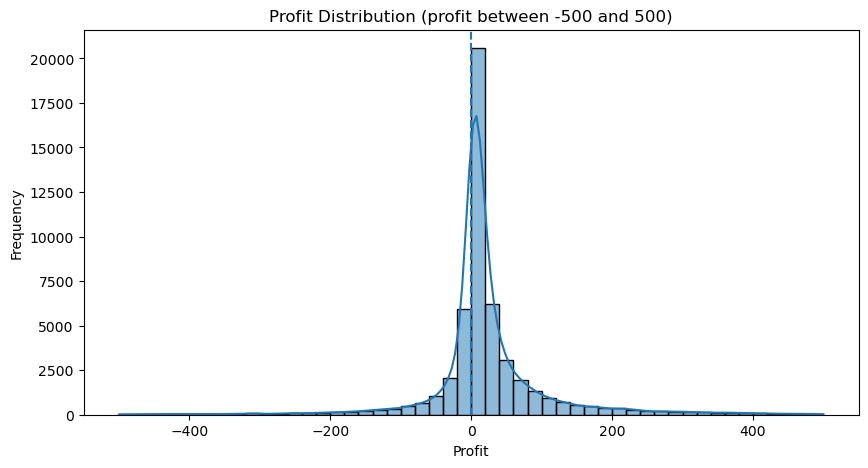

In [47]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df.loc[df["profit"].between(-500, 500), "profit"],
    bins=50,
    kde=True
)

plt.title("Profit Distribution (profit between -500 and 500)")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.axvline(0, linestyle="--")

plt.show()

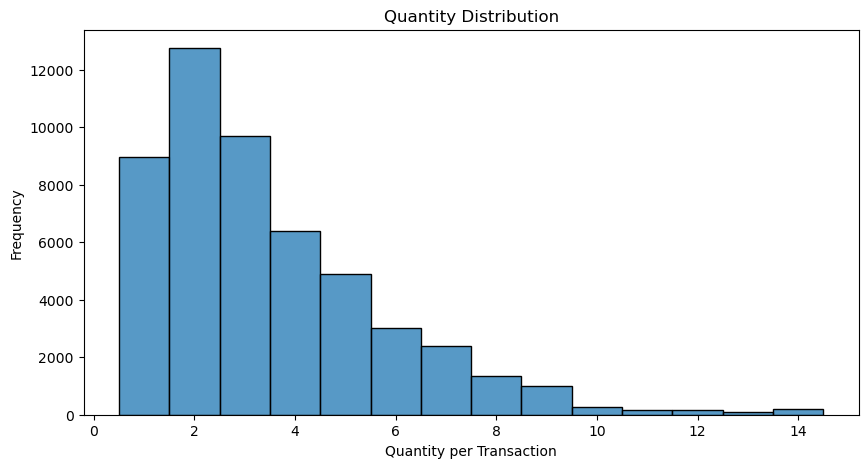

In [48]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["quantity"],
    bins=14,
    discrete=True
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity per Transaction")
plt.ylabel("Frequency")

plt.show()

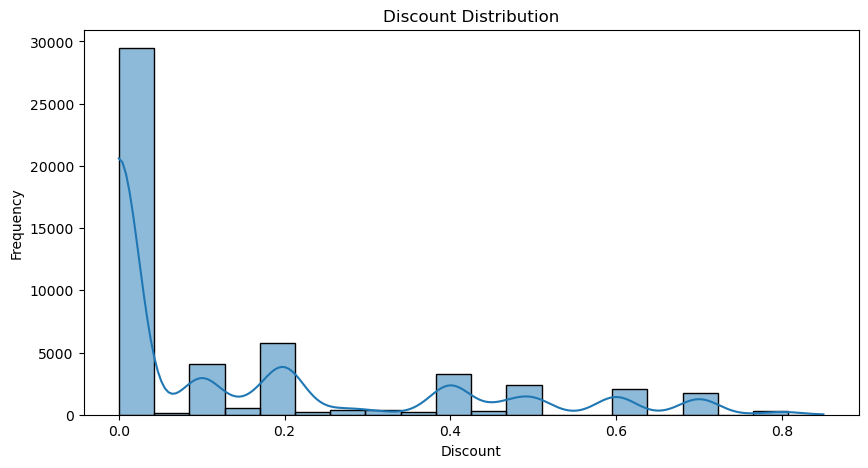

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["discount"],
    bins=20,
    kde=True
)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")

plt.show()

**Mean vs median** (a big gap means the data is skewed)

In [50]:
mean_sales = df["sales"].mean()
median_sales = df["sales"].median()

print("Mean Sales:", round(mean_sales, 2))
print("Median Sales:", round(median_sales, 2))

Mean Sales: 246.5
Median Sales: 85.0


In [51]:
mean_profit = df["profit"].mean()
median_profit = df["profit"].median()

print("Mean Profit:", round(mean_profit, 2))
print("Median Profit:", round(median_profit, 2))

Mean Profit: 28.64
Median Profit: 9.24


### Insights — Distributions
- **Sales is right-skewed.** The mean (\$246.50) is almost 3× the median (\$85), and 75% of transactions are below \$251. A small number of very large orders (up to \$22,638) pull the average up.
- **Profit is also right-skewed.** The mean is \$28.64 and the median only \$9.24, so a typical transaction earns a small profit. There are also extreme values at both ends (-\$6,600 to +\$8,400).
- **Quantity** per transaction is small: most transactions have 1–4 units (the most common is 2), with a maximum of 14.
- **Discount:** more than half of the transactions have **no discount**. The rest are concentrated at specific levels like 10%, 20%, 40%, 50%, 60% and 70%.
- **Takeaway:** because of the skew, **median is a better "typical" value than mean** here.

## 15. Outlier Detection (IQR Method)
Outliers are values outside `Q1 - 1.5 × IQR` and `Q3 + 1.5 × IQR`.

In [52]:
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = df[
    (df["sales"] < lower_bound) |
    (df["sales"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Sales Outliers:", len(sales_outliers))

Q1: 31.0
Q3: 251.0
IQR: 220.0
Lower Bound: -299.0
Upper Bound: 581.0
Number of Sales Outliers: 5655


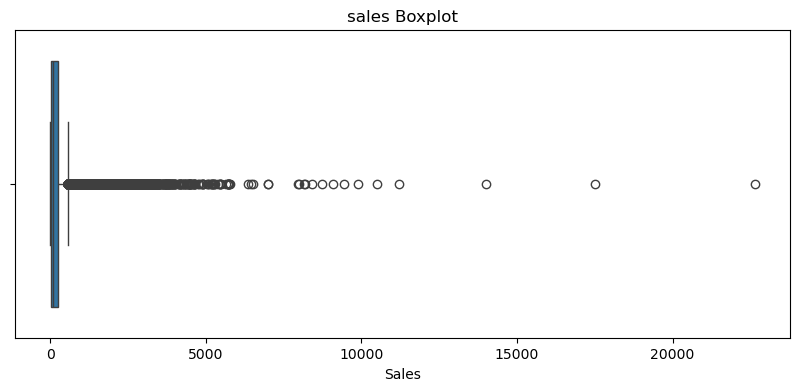

In [53]:
plt.figure(figsize = (10, 4))
sns.boxplot(x = df["sales"])

plt.title("sales Boxplot")
plt.xlabel("Sales")

plt.show()

In [54]:
Q1 = df["profit"].quantile(0.25)
Q3 = df["profit"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

profit_outliers = df[
    (df["profit"] < lower_bound) |
    (df["profit"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Profit Outliers:", len(profit_outliers))

Q1: 0.0
Q3: 36.81
IQR: 36.81
Lower Bound: -55.215
Upper Bound: 92.025
Number of Profit Outliers: 9755


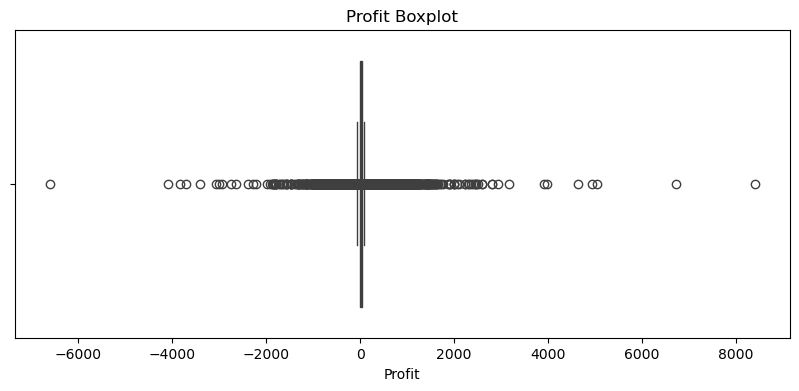

In [55]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["profit"])

plt.title("Profit Boxplot")
plt.xlabel("Profit")

plt.show()

### Insights — Outliers
- **Sales:** upper limit is \$581 and **5,655 transactions (11%)** are above it.
- **Profit:** the normal range is about -\$55 to +\$92 and **9,755 transactions (19%)** are outside it.
- These are **genuine business transactions** (large orders and heavily discounted loss-making sales), not data errors. They are the exact rows that explain the losses found earlier, so **they are kept** and not removed.

## 16. Relationships Between Variables

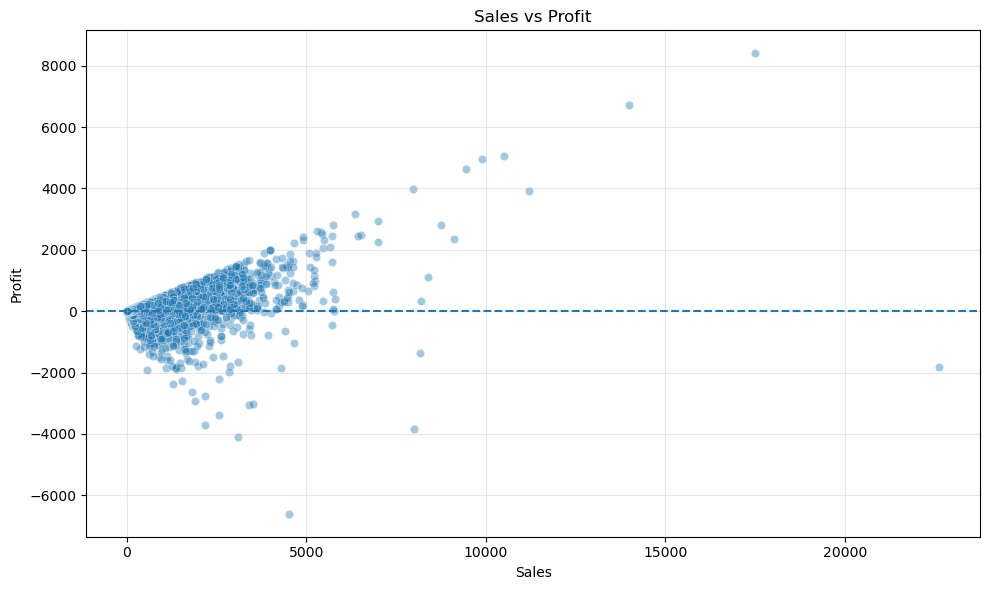

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit",
    alpha=0.4
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.axhline(0, linestyle="--")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

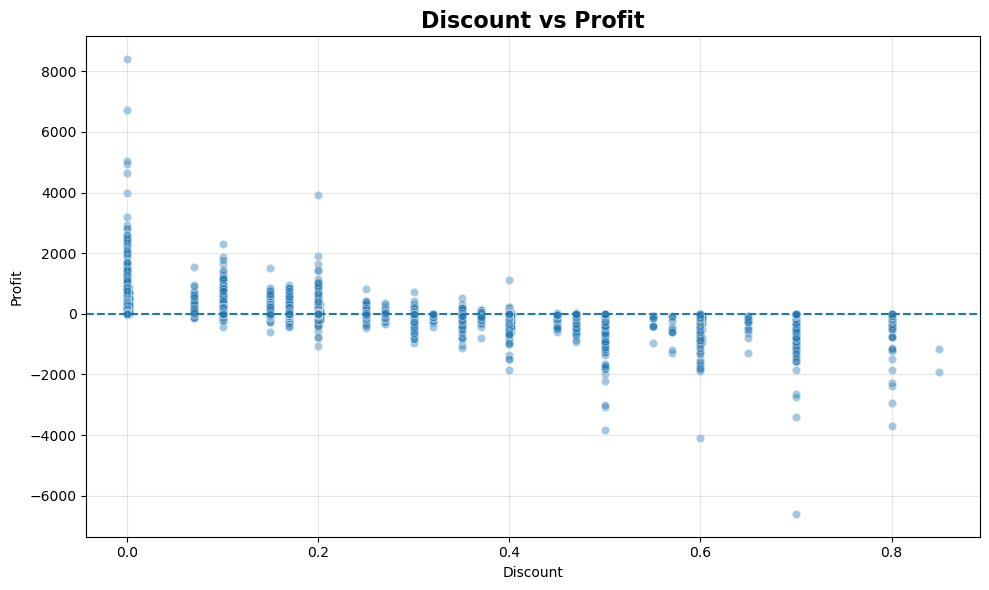

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    alpha=0.4
)

plt.title("Discount vs Profit", fontsize=16, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.axhline(0, linestyle="--")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

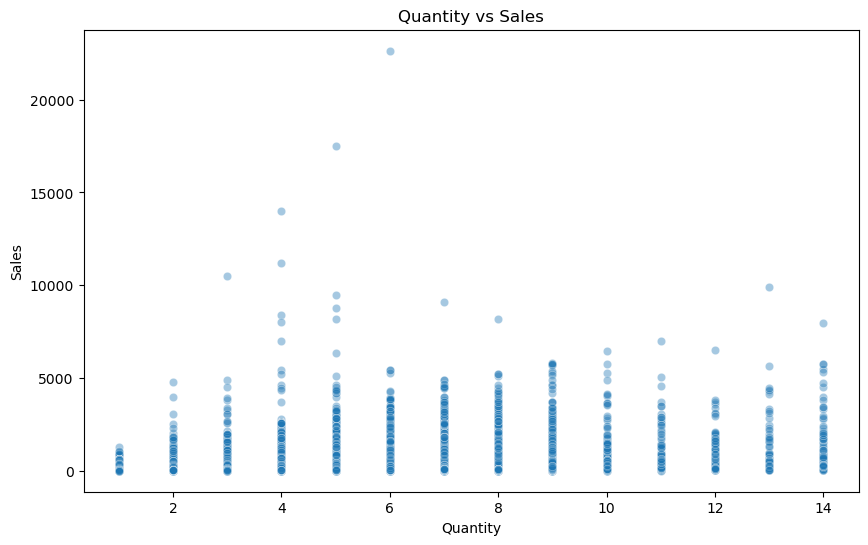

In [58]:
plt.figure(figsize = (10, 6))

sns.scatterplot(
    data = df,
    x = "quantity",
    y = "sales",
    alpha = 0.4
)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

In [59]:
correlation_matrix = df[
    ["sales", "profit", "quantity", "discount"]
    ].corr()

print(correlation_matrix)

             sales    profit  quantity  discount
sales     1.000000  0.485944  0.313580 -0.086728
profit    0.485944  1.000000  0.104743 -0.316375
quantity  0.313580  0.104743  1.000000 -0.019875
discount -0.086728 -0.316375 -0.019875  1.000000


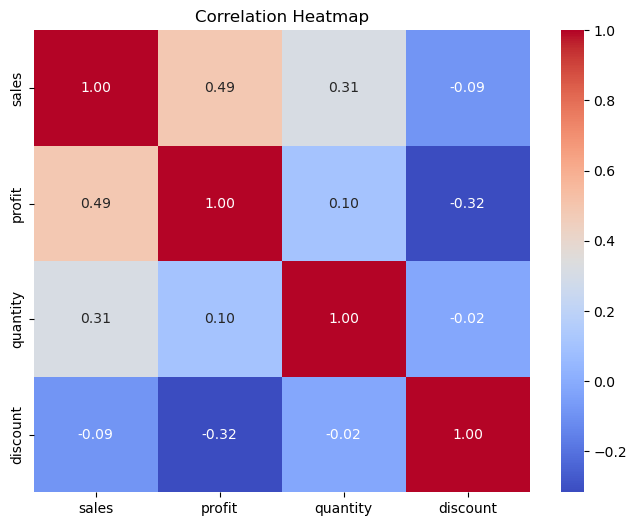

In [60]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Insights — Relationships
- **Sales vs Profit (0.49):** moderate positive relationship. Bigger sales usually mean more profit, but many high-sales points are still below zero profit.
- **Discount vs Profit (-0.32):** moderate **negative** relationship, the strongest negative link in the data. In the scatter plot, once the discount goes to about 50% and above, almost every transaction is loss-making.
- **Quantity vs Sales (0.31):** weak-to-moderate. Buying more units raises sales a little, but price per unit matters more.
- **Discount vs Quantity (-0.02):** almost no relationship, so **bigger discounts did not make customers buy more units per transaction** in this data.
- **Takeaway:** discounts reduce profit without a visible gain in quantity.

## 17. Visual Summary
Final charts to summarise the main results.

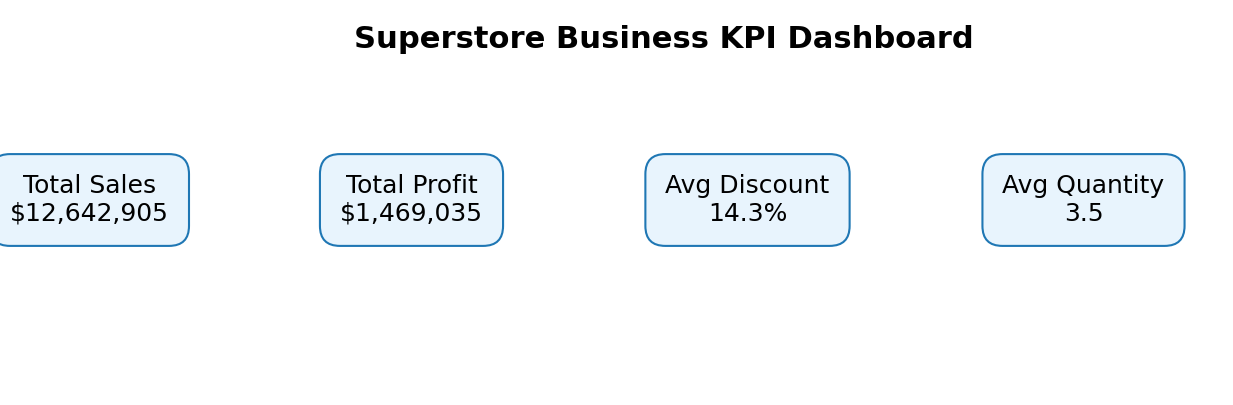

In [61]:
fig = plt.figure(figsize=(14, 5))
fig.patch.set_facecolor("white")

kpis = [
    ("Total Sales", f"${df['sales'].sum():,.0f}"),
    ("Total Profit", f"${df['profit'].sum():,.0f}"),
    ("Avg Discount", f"{df['discount'].mean()*100:.1f}%"),
    ("Avg Quantity", f"{df['quantity'].mean():.1f}")
]

positions = [
    (0.09, 0.50),
    (0.32, 0.50),
    (0.56, 0.50),
    (0.80, 0.50)
]

for (title, value), (x, y) in zip(kpis, positions):

    plt.figtext(
        x,
        y,
        f"{title}\n{value}",
        ha="center",
        va="center",
        fontsize=18,
        bbox=dict(
            boxstyle="round,pad=0.8",
            facecolor="#E8F4FD",
            edgecolor="#1F77B4",
            linewidth=1.5
        )
    )

plt.axis("off")

plt.suptitle(
    "Superstore Business KPI Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.85
)

plt.show()

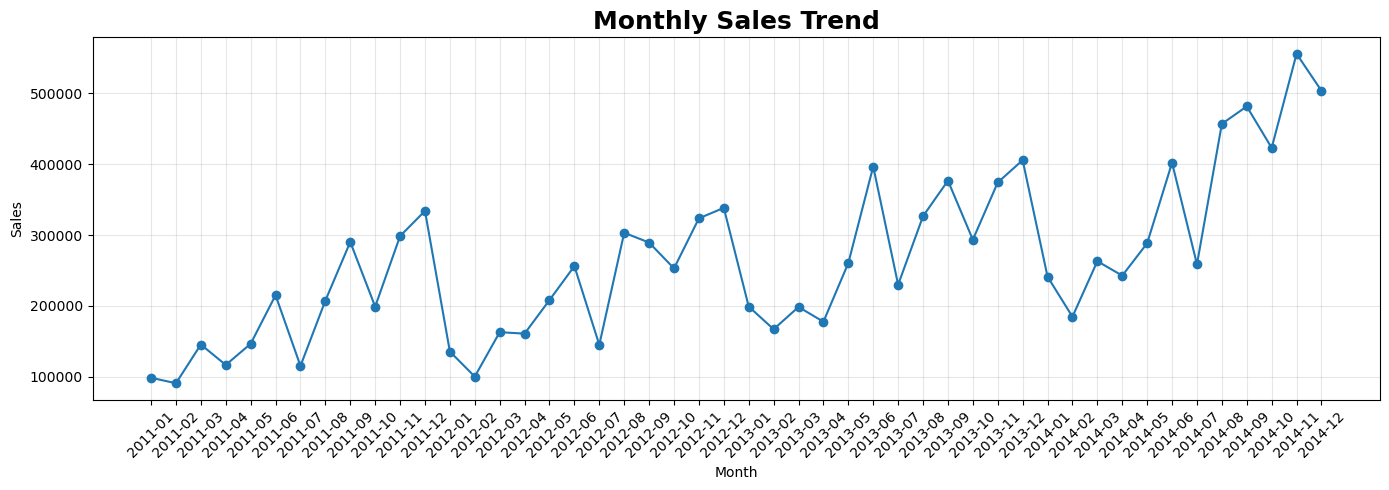

In [62]:
monthly_sales = (
    df.groupby(df["order_date"].dt.to_period("M"))["sales"]
      .sum()
      .reset_index()
)

monthly_sales["order_date"] = monthly_sales["order_date"].astype(str)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=18, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

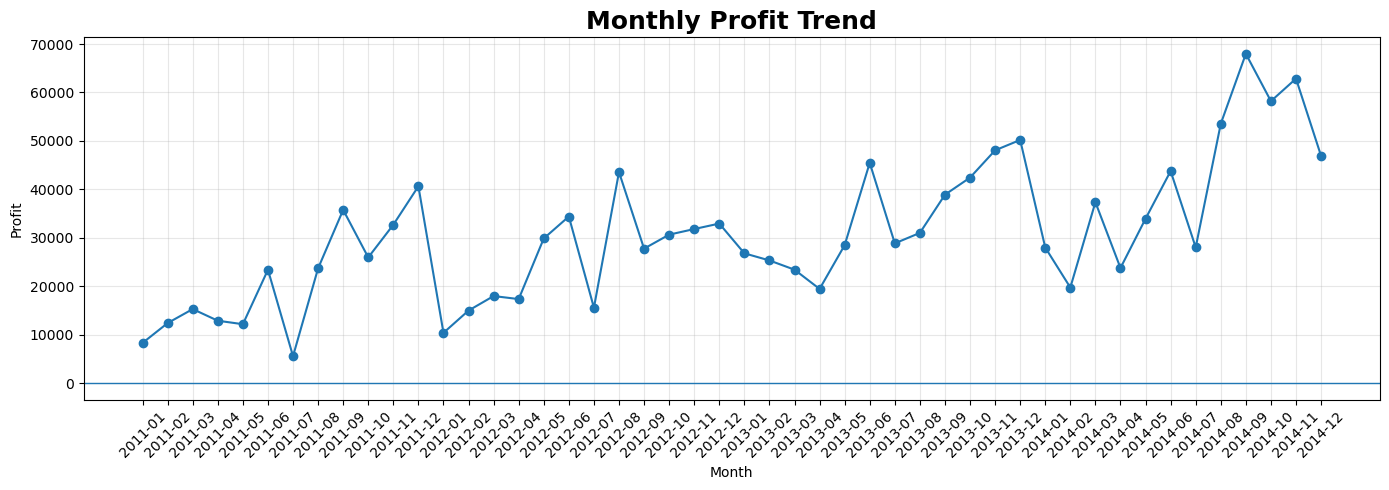

In [63]:
monthly_profit = (
    df.groupby(df["order_date"].dt.to_period("M"))["profit"]
      .sum()
      .reset_index()
)

monthly_profit["order_date"] = monthly_profit["order_date"].astype(str)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_profit["order_date"],
    monthly_profit["profit"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.title("Monthly Profit Trend", fontsize=18, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
category_chart = (
    df.groupby("category")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

category_chart["profit_margin"] = (
    category_chart["profit"] / category_chart["sales"] * 100
).round(2)

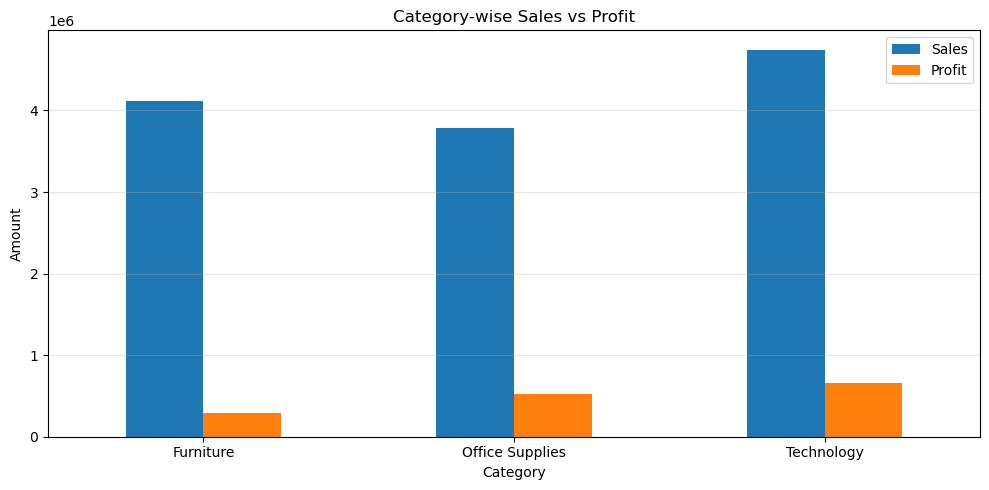

In [65]:
category_chart.plot(
    x="category",
    y=["sales", "profit"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Category-wise Sales vs Profit")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

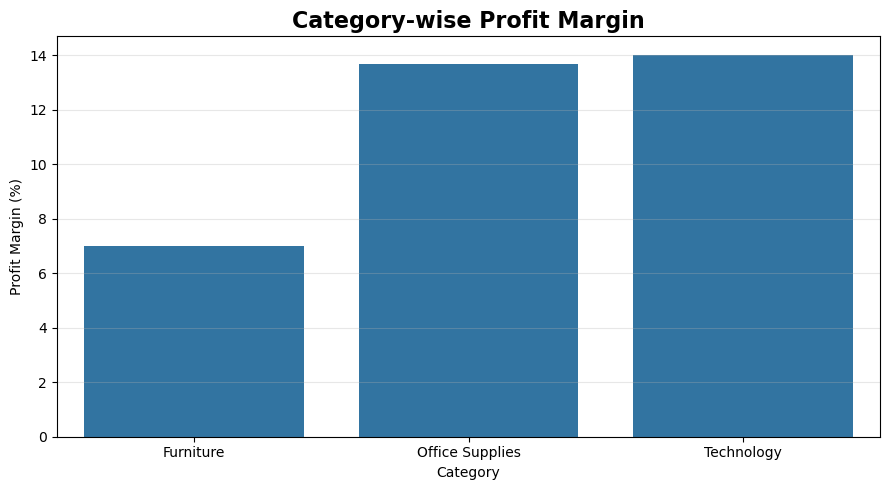

In [66]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_chart,
    x="category",
    y="profit_margin"
)

plt.title("Category-wise Profit Margin", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
subcategory_chart = (
    df.groupby("sub_category")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

subcategory_chart["profit_margin"] = (
    subcategory_chart["profit"]
    / subcategory_chart["sales"]
    * 100
).round(2)

subcategory_chart = subcategory_chart.sort_values(
    "profit",
    ascending=True
)

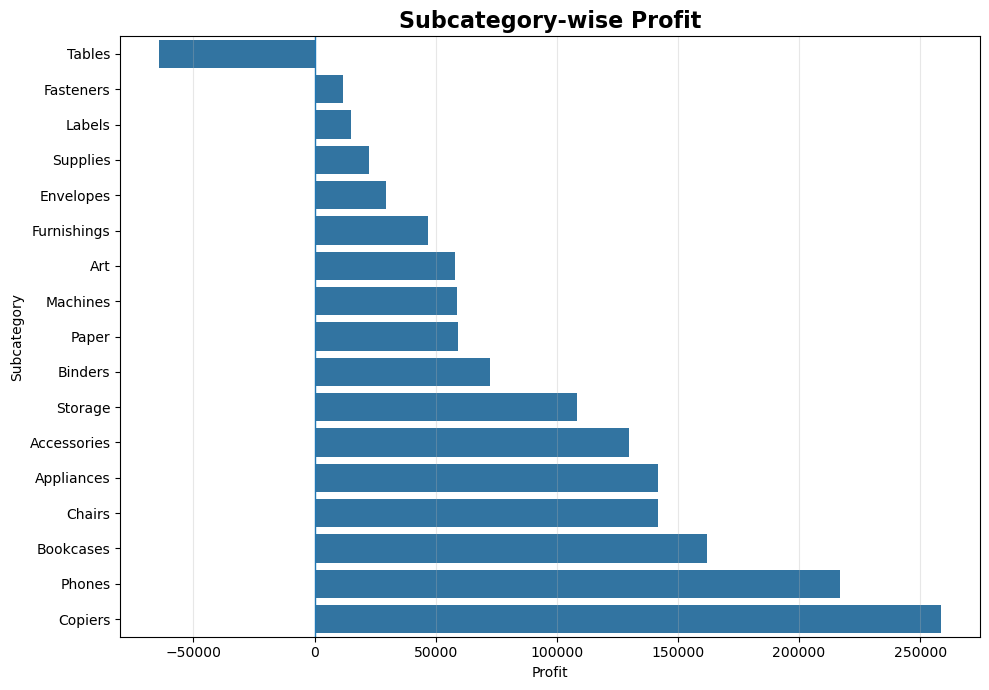

In [68]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=subcategory_chart,
    x="profit",
    y="sub_category"
)

plt.title("Subcategory-wise Profit", fontsize=16, fontweight="bold")
plt.xlabel("Profit")
plt.ylabel("Subcategory")

plt.axvline(0, linewidth=1)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
region_chart = (
    df.groupby("region")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

region_chart["profit_margin"] = (
    region_chart["profit"]
    / region_chart["sales"]
    * 100
).round(2)

region_chart = region_chart.sort_values(
    "profit",
    ascending=False
)

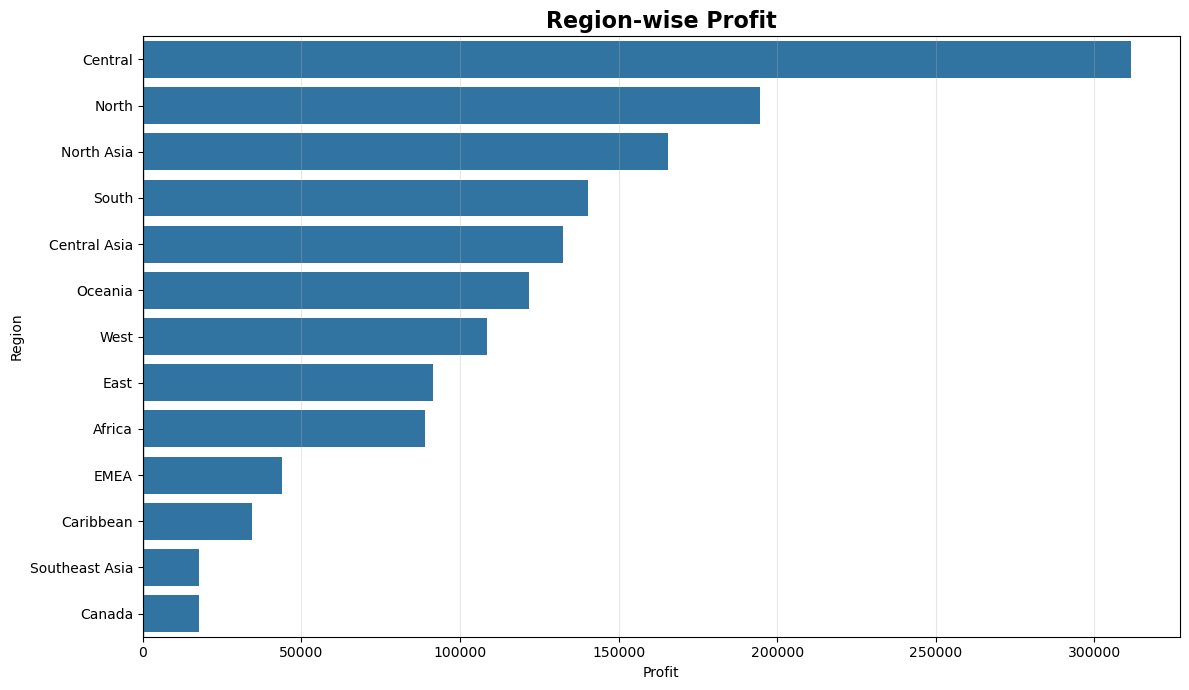

In [70]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=region_chart,
    x="profit",
    y="region"
)

plt.title("Region-wise Profit", fontsize=16, fontweight="bold")
plt.xlabel("Profit")
plt.ylabel("Region")

plt.axvline(0, linewidth=1)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
segment_chart = (
    df.groupby("segment")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

segment_chart["profit_margin"] = (
    segment_chart["profit"]
    / segment_chart["sales"]
    * 100
).round(2)

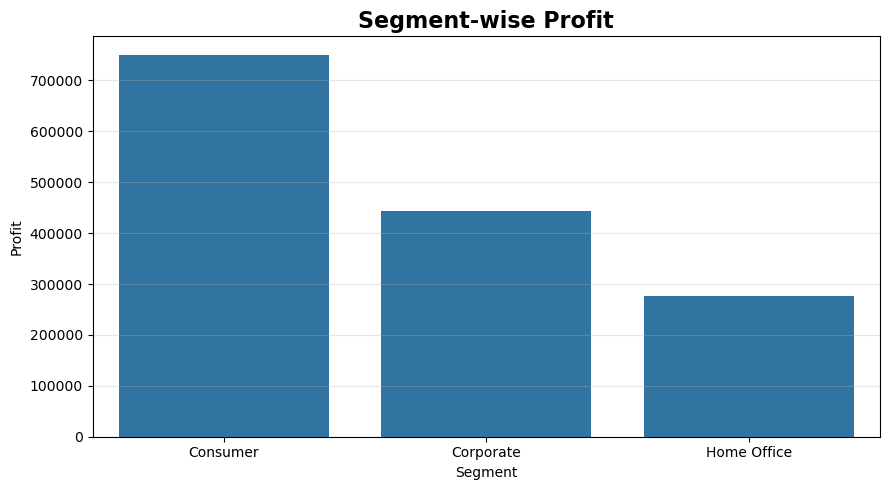

In [72]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_chart,
    x="segment",
    y="profit"
)

plt.title("Segment-wise Profit", fontsize=16, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Insights — Visual Summary
- **Monthly trend:** both sales and profit move upward from 2011 to 2014 with a repeating pattern: low start of the year, a June peak, a July dip and a big finish in Q4.
- **Category chart:** Technology leads in both sales and profit, while Furniture's profit bar is very short compared to its sales.
- **Sub-category chart:** Tables is the only bar below zero. Copiers and Phones are the biggest profit makers.
- **Region chart:** Central is far ahead in profit. Southeast Asia and Canada are at the bottom for different reasons (low margin vs small sales).
- **Segment chart:** profit follows sales (Consumer > Corporate > Home Office) because margins are almost equal.

## 18. Final Insights, Recommendations and Next Steps

### Key Findings
1. **Overall:** \$12.64M sales, \$1.47M profit, **11.62% profit margin**, 25,035 orders.
2. **Discounts are the biggest profit leak.** Transactions with a discount above 20% (22% of all transactions) lost about **\$815K**, while transactions with no discount earned \$1.77M.
3. **Tables** is the only loss-making sub-category (-\$64K) because of discounts of 30% and more, not because of weak demand.
4. **Technology** gives 45% of the profit and **Furniture** only 19.5% of profit from 32.5% of sales.
5. **Southeast Asia (2.0% margin), EMEA (5.5%) and South (8.8%)** have the weakest margins.
6. Sales grew about **90% from 2011 to 2014** with a stable ~11–12% margin. Q4 is the peak season.
7. A few **heavily discounted orders** (e.g. a 3D printer sold at a 70% discount) can create large losses for otherwise good customers.

### Recommendations
- **Cap discounts at about 20%**, and add an approval step for anything higher.
- **Review pricing and discounts for Tables**, Machines, Chairs and Storage (high sales, low margin).
- **Check low-margin regions** (Southeast Asia, EMEA, South) for heavy discounting and other costs.
- **Focus on high-profit lines** like Copiers and Phones, and plan stock and campaigns around Q4 and June.
- **Monitor loss-making customers and products** regularly.

### Limitations
- The analysis is descriptive: it shows *what* happened, not a proven *why*.
- Product cost is not available, so loss causes for some products (e.g. low-discount losses) cannot be confirmed.

### Next Steps
- Analyse **shipping cost** and **delivery time** (`ship_date - order_date`), which are not analysed yet.
- Build an interactive **Power BI dashboard** from these results.
- Try a simple sales **forecast** using the monthly trend.